In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [49]:
df= pd.read_csv("./datasets/logistic.csv")

[]

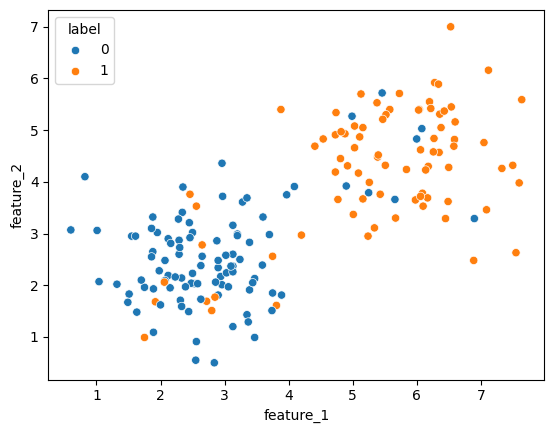

In [50]:
sns.scatterplot(x= df['feature_1'], y= df['feature_2'], hue= df['label'])
plt.plot()

In [51]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(df.iloc[:, 0:-1], df.iloc[:, -1], random_state= 42)

In [52]:
x_train

,feature_1,feature_2
132,6.00,4.83
90,5.34,3.11
38,2.31,1.71
169,2.63,1.73
115,4.73,4.91
...,...,...
71,2.48,2.04
106,3.59,2.39
14,2.12,2.19
92,7.05,4.76


In [53]:
from sklearn.linear_model import LogisticRegression

lr= LogisticRegression()

lr.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [54]:
y_pred= lr.predict(x_test)   #In standard the threshold is 0.5
y_pred

array([1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1])

In [55]:
y_prob_raw= lr.predict_proba(x_test)  #gives the value of sigmoid function(probability). It gives the probability of that point being negative and positive
y_prob_raw

array([[0.042166  , 0.957834  ],
       [0.85409541, 0.14590459],
       [0.97139511, 0.02860489],
       [0.99176057, 0.00823943],
       [0.35565795, 0.64434205],
       [0.97033101, 0.02966899],
       [0.95307039, 0.04692961],
       [0.64031469, 0.35968531],
       [0.01835229, 0.98164771],
       [0.08653284, 0.91346716],
       [0.41346644, 0.58653356],
       [0.83567287, 0.16432713],
       [0.98013366, 0.01986634],
       [0.95316672, 0.04683328],
       [0.85152668, 0.14847332],
       [0.98678348, 0.01321652],
       [0.98131019, 0.01868981],
       [0.97247682, 0.02752318],
       [0.28244512, 0.71755488],
       [0.04255865, 0.95744135],
       [0.28135056, 0.71864944],
       [0.15802281, 0.84197719],
       [0.11495344, 0.88504656],
       [0.92797184, 0.07202816],
       [0.03776514, 0.96223486],
       [0.97318664, 0.02681336],
       [0.86868928, 0.13131072],
       [0.78494085, 0.21505915],
       [0.05826548, 0.94173452],
       [0.92474802, 0.07525198],
       [0.

In [56]:
y_prob= y_prob_raw[:, 1]  # as we only want prob of it being positive in roc-auc
y_prob

array([0.957834  , 0.14590459, 0.02860489, 0.00823943, 0.64434205,
       0.02966899, 0.04692961, 0.35968531, 0.98164771, 0.91346716,
       0.58653356, 0.16432713, 0.01986634, 0.04683328, 0.14847332,
       0.01321652, 0.01868981, 0.02752318, 0.71755488, 0.95744135,
       0.71864944, 0.84197719, 0.88504656, 0.07202816, 0.96223486,
       0.02681336, 0.13131072, 0.21505915, 0.94173452, 0.07525198,
       0.12972367, 0.93703817, 0.83066969, 0.89938129, 0.03374959,
       0.9783526 , 0.77358456, 0.75082666, 0.07875753, 0.21091478,
       0.03662782, 0.20948025, 0.66902519, 0.79130221, 0.92447751])

In [57]:
# accuracy metrices

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

print('Accuracy score', accuracy_score(y_test, y_pred))
print('Precision score', precision_score(y_test, y_pred))
print('recall score', recall_score(y_test, y_pred))
print('f1 score', f1_score(y_test, y_pred))

Accuracy score 0.7555555555555555
Precision score 0.8571428571428571
recall score 0.6923076923076923
f1 score 0.7659574468085106


In [58]:
confusion_matrix(y_test, y_pred)

array([[16,  3],
       [ 8, 18]])

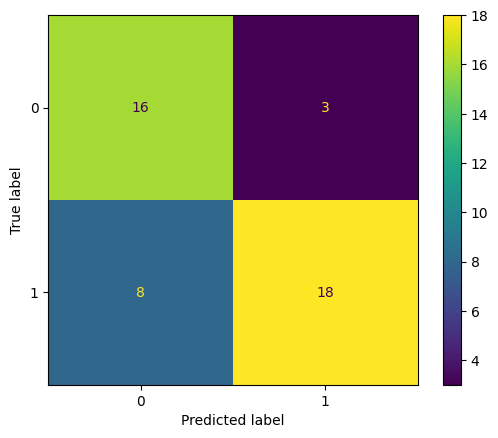

In [59]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_true= y_test,
    y_pred= y_pred
)

In [60]:
# to find the good threshold we use ROC-AUC curve
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

fpr, tpr, thresholds= roc_curve(y_true= y_test, y_score= y_prob)



In [61]:
fpr

array([0.        , 0.        , 0.        , 0.05263158, 0.05263158,
       0.10526316, 0.10526316, 0.15789474, 0.15789474, 0.26315789,
       0.26315789, 0.36842105, 0.36842105, 0.52631579, 0.52631579,
       0.57894737, 0.57894737, 0.84210526, 0.84210526, 0.89473684,
       0.89473684, 1.        ])

In [62]:
tpr

array([0.        , 0.03846154, 0.19230769, 0.19230769, 0.42307692,
       0.42307692, 0.5       , 0.5       , 0.73076923, 0.73076923,
       0.76923077, 0.76923077, 0.80769231, 0.80769231, 0.84615385,
       0.84615385, 0.92307692, 0.92307692, 0.96153846, 0.96153846,
       1.        , 1.        ])

In [63]:
thresholds

array([       inf, 0.98164771, 0.95744135, 0.94173452, 0.84197719,
       0.83066969, 0.77358456, 0.75082666, 0.35968531, 0.21091478,
       0.20948025, 0.14847332, 0.14590459, 0.07875753, 0.07525198,
       0.07202816, 0.04683328, 0.02752318, 0.02681336, 0.01986634,
       0.01868981, 0.00823943])

In [64]:
#  to select the best threshold

j_score= tpr - fpr    #we need thershold having high tpr and less fpr
best_idx= np.argmax(j_score)    #gives the index having heighest value from j_score array

thresholds[best_idx]



np.float64(0.3596853147099023)

In [75]:
roc_auc_score(y_true= y_test, y_score= y_prob)

0.7874493927125507

c:\Users\Yunish\miniconda3\envs\myenv\Lib\site-packages\sklearn\utils\_plotting.py:440: FutureWarning: y_pred was deprecated in 1.7 and will be removed in 1.9. Please use `y_score` instead.
  warnings.warn(


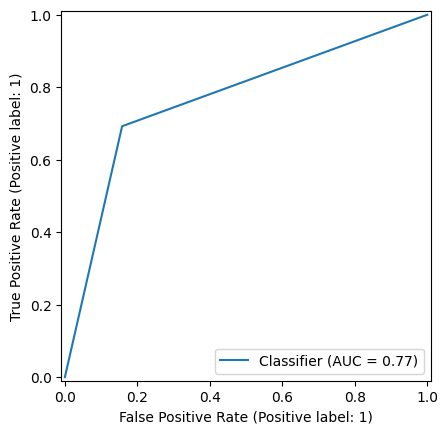

In [66]:
RocCurveDisplay.from_predictions(y_true= y_test, y_pred= y_pred)

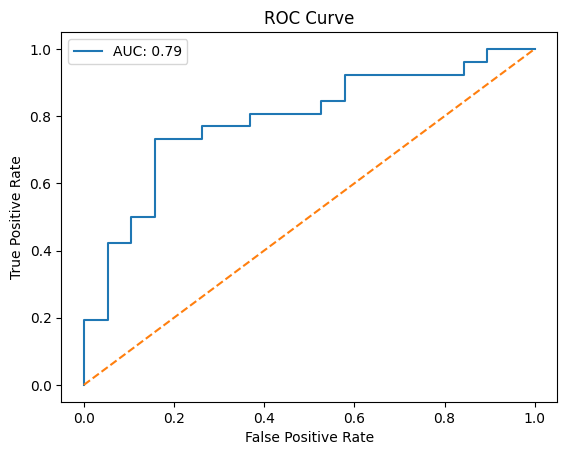

In [74]:
plt.plot(fpr, tpr, label= f"AUC: {auc(fpr, tpr):.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [70]:
from sklearn.metrics import auc

auc(fpr, tpr)

0.7874493927125507